# 05 Time Series Analysis - Business Trend and Forecasting

## Project Background
In e-commerce business, performance evolves continuously over time. Order volume, GMV, customer activity, and product demand are all influenced by temporal factors such as long-term growth, seasonality, weekly shopping habits, hourly purchase behavior, and occasional abnormal fluctuations. Therefore, analysing business performance only from a static overall perspective is not sufficient. A time-based perspective is necessary to understand how the business changes, when demand peaks occur, and how future performance may develop.

This project is based on order transaction data from the e-commerce data warehouse. It aims to conduct a systematic time series analysis of business performance, from descriptive trend analysis to seasonal decomposition, anomaly detection, category-level temporal comparison, and forecasting model construction. By examining the platform's order behavior across multiple time granularities, this project helps reveal the dynamic structure of demand and supports more informed operational planning.

## Project Objectives
- Understanding long-term business trends and temporal evolution patterns
- Identify seasonal, weekly, and hourly ordering behavior
- Detect anomalies and unusual fluctuations in the time series
- Compare temporal sales patterns across major product categories
- Build time series forcasting models for short-term prediction
- Provide actionable recommendations for operations, inventory and marketing

## Key Business Questions
1. What is the overall trend in order volume and GMV? Is the business growing, stable, or declining?
2. Are there clear seasonal patterns in the business? Which months are peak periods?
3. Which days of the week and which hours of the day show the highest order activity?
4. Are there any abnormal fluctuations or unusual turning points in the time series?
5. Do different product categories exhibit different temporal demand patterns?
6. What is the forecast for the next 1 to 3 months?

## Analytical Framework
- Time series data loading and preprocessing
- Descriptive analysis of trends at daily, monthly, weekly, and hourly levels
- Seasonal decomposition into trend, seasonal and residual components
- Stationarity testing and autocorrelation analysis
- Anomaly detection based on residual behavior
- Category-level temporal comparison
- Forecasting model development (Native, Moving Average, ARIMA, Exponential Smoothing, Prophet)
- Model evaluation and business recommendation generation

## 1. Data Loading & Initial Exploration

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Time series analysis libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Libraries imported successfully")

 Libraries imported successfully


In [4]:
# Load order-level transactional data from MySQL data warehouse
from src.utils.db import get_engine

engine = get_engine()

sql_orders = """
SELECT
    o.order_id,
    o.purchase_ts AS order_purchase_timestamp,
    o.delivered_ts AS order_delivered_customer_date,
    o.estimated_delivery_ts AS order_estimated_delivery_date,
    oi.price,
    oi.freight_value,
    oi.product_id,
    p.category AS category_name_english,
    u.state AS customer_state
FROM fact_order o
JOIN fact_order_item oi
    ON o.order_id = oi.order_id
JOIN dim_product p
    ON oi.product_id = p.product_id
JOIN dim_user u
    ON o.user_id = u.user_id
WHERE o.order_status = 'delivered'
  AND o.purchase_ts IS NOT NULL
"""

df_orders = pd.read_sql(sql_orders, engine)
engine.dispose()

print(f"Loaded {len(df_orders):,} order records")
print(f"Date range: {df_orders['order_purchase_timestamp'].min()} to {df_orders['order_purchase_timestamp'].max()}")

df_orders.head()

Loaded 110,197 order records
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,product_id,category_name_english,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,RJ
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,MG
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,12.99,12.79,7634da152a4610f1595efa32f14722fc,perfumaria,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,199.90,18.14,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,SP


In [5]:
# Convert timestamp columns to datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

# Create date-based features for time series analysis
df_orders['order_date'] = df_orders['order_purchase_timestamp'].dt.date
df_orders['order_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['order_month'] = df_orders['order_purchase_timestamp'].dt.month
df_orders['order_week'] = df_orders['order_purchase_timestamp'].dt.isocalendar().week
df_orders['order_dayofweek'] = df_orders['order_purchase_timestamp'].dt.dayofweek
df_orders['order_hour'] = df_orders['order_purchase_timestamp'].dt.hour
df_orders['order_day_name'] = df_orders['order_purchase_timestamp'].dt.day_name()

# Calculate GMV
df_orders['gmv'] = df_orders['price'] + df_orders['freight_value']

print("✓ Datetime conversion completed")
print("✓ Time-based features created successfully")
print("✓ GMV column created successfully")

✓ Datetime conversion completed
✓ Time-based features created successfully
✓ GMV column created successfully


In [6]:
# Check missing values in key fields
print("=" * 60)
print("Missing Value Check")
print("=" * 60)

missing_summary = df_orders[
    ['order_purchase_timestamp', 'price', 'freight_value', 'category_name_english', 'customer_state']
].isnull().sum()

print(missing_summary)

Missing Value Check
order_purchase_timestamp       0
price                          0
freight_value                  0
category_name_english       1537
customer_state                 0
dtype: int64


In [7]:
# Display basic dataset information
print("=" * 60)
print("Dataset Structure")
print("=" * 60)

print(f"Shape of dataset: {df_orders.shape}")
print("\nData types:")
print(df_orders.dtypes)

print("\nBasic descriptive statistics:")
display(df_orders[['price', 'freight_value', 'gmv', 'order_year', 'order_month', 'order_hour']].describe())

Dataset Structure
Shape of dataset: (110197, 17)

Data types:
order_id                                    str
order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
price                                   float64
freight_value                           float64
product_id                                  str
category_name_english                       str
customer_state                              str
order_date                               object
order_year                                int32
order_month                               int32
order_week                               UInt32
order_dayofweek                           int32
order_hour                                int32
order_day_name                              str
gmv                                     float64
dtype: object

Basic descriptive statistics:


,price,freight_value,gmv,order_year,order_month,order_hour
count,110197.000000,110197.000000,110197.000000,110197.000000,110197.000000,110197.000000
mean,119.980563,19.948598,139.929161,2017.544543,6.031634,14.748959
std,182.299446,15.698136,189.319151,0.503757,3.230682,5.314665
min,0.850000,0.000000,6.080000,2016.000000,1.000000,0.000000
25%,39.900000,13.080000,55.180000,2017.000000,3.000000,11.000000
50%,74.900000,16.260000,92.130000,2018.000000,6.000000,15.000000
75%,134.170000,21.150000,157.510000,2018.000000,8.000000,19.000000
max,6735.000000,409.680000,6929.310000,2018.000000,12.000000,23.000000


In [8]:
# Preview the processed dataset
df_orders.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,product_id,category_name_english,customer_state,order_date,order_year,order_month,order_week,order_dayofweek,order_hour,order_day_name,gmv
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,RJ,2017-09-13,2017,9,37,2,8,Wednesday,72.19
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f,pet_shop,SP,2017-04-26,2017,4,17,2,10,Wednesday,259.83
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,MG,2018-01-14,2018,1,2,6,14,Sunday,216.87
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,12.99,12.79,7634da152a4610f1595efa32f14722fc,perfumaria,SP,2018-08-08,2018,8,32,2,10,Wednesday,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,199.90,18.14,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,SP,2017-02-04,2017,2,5,5,13,Saturday,218.04


### Initial Observation
The order-level dataset was successfully loaded from the data warehouse and contains complete timestamp information required for time series analysis. After preprocessing, multiple temporal features were generated, including year, month, week, weekday, and hour, which provide the basis for multi-granularity business trend analysis. In addition, GMV was calculated at the order-item level, allowing the project to analyse both order volume and revenue dynamics over time.

### Data Quality Reflection
The dataset shows strong overall completeness in the core fields required for time series modelling. No missing values were observed in purchase timestamp, price, freight value, or customer state, which ensures that the subsequent analyses of trend, seasonality, anomaly detection, and forecasting are based on reliable temporal and monetary information.

A minor data quality issue exists in the product category field, where approximately 1.39% of records have missing category labels. While this does not significantly affect the overall business trend analysis, it may introduce bias or ambiguity in category-level comparisons. For this reason, the full dataset is retained for aggregate time series analysis, while category-based analysis is conducted on a filtered subset with valid category information only.

## 2. Descriptive Time Series Analysis
This section explores the temporal structure of the e-commerce business from multiple granularities, including daily, monthly, weekly, and hourly levels.

A key methodological point is that the dataset is recorded at the order-item level. Therefore, order volume should be measured using unique `order_id` rather than raw row count, while GMV can be aggregated by summing item-level values.

## 2.1 Daily Trend of Order Volume and GMV
Daily aggregation provides the base time series for understanding short-term fluctuations, local peaks, and overall business movement.

Here, daily order volume is calculated using unique orders, while daily GMV is measured by total transaction value.

In [9]:
# Aggregate to daily level
# Use unique order_id for order count because the dataset is at order-item level

df_daily = df_orders.groupby('order_date').agg(
    order_count=('order_id', 'nunique'),
    gmv=('gmv', 'sum')
).reset_index()

df_daily['order_date'] = pd.to_datetime(df_daily['order_date'])
df_daily = df_daily.sort_values('order_date')

print(df_daily.shape)
df_daily.head()

(612, 3)


,order_date,order_count,gmv
0,2016-09-15,1,143.46
1,2016-10-03,7,559.53
2,2016-10-04,54,9821.42
3,2016-10-05,35,7209.50
4,2016-10-06,41,6798.90


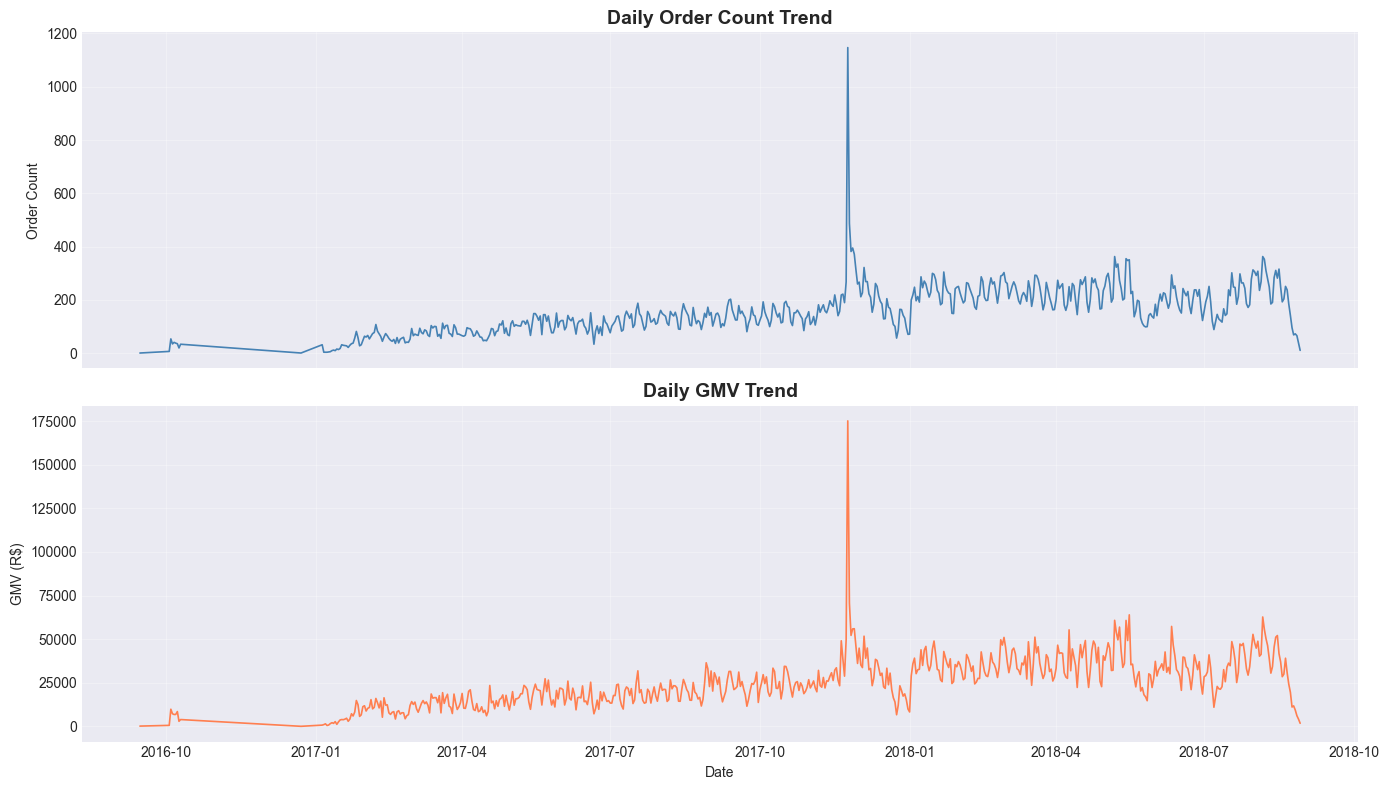

Date range: 2016-09-15 to 2018-08-29
Total days: 612
Average daily order count: 157.64
Average daily GMV: 25195.71


In [10]:
# Plot daily order count and GMV trend

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily order count
axes[0].plot(
    df_daily['order_date'],
    df_daily['order_count'],
    color='steelblue',
    linewidth=1.2
)
axes[0].set_title('Daily Order Count Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Order Count')
axes[0].grid(True, alpha=0.3)

# Daily GMV
axes[1].plot(
    df_daily['order_date'],
    df_daily['gmv'],
    color='coral',
    linewidth=1.2
)
axes[1].set_title('Daily GMV Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('GMV (R$)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Date range: {df_daily['order_date'].min().date()} to {df_daily['order_date'].max().date()}")
print(f"Total days: {len(df_daily)}")
print(f"Average daily order count: {df_daily['order_count'].mean():.2f}")
print(f"Average daily GMV: {df_daily['gmv'].mean():.2f}")

### Daily Trend Interpretation
The daily time series shows a clear overall upward trend in both order volume and GMV from late 2016 to mid-2018, indicating that the platform experienced substantial business growth over time. At the same time, the series becomes more volatile in the later period, suggesting that business expansion was accompanied by stronger short-term fluctuations. Avery prominent spike appears around late 2017, which likely reflects a major promotional-event or abnormal demand surge rather than normal daily behavior. In addition, the sharp drop at the end of the series is likely caused by incomplete data for the final observation period, so it should be interpreted with caution rather than treated as a real business decline.

## 2.2 Monthly Aggregation and Medium-Term Trend
Monthly aggregation helps smooth daily noise and reveals broader changes in business scale and demand pattern.

To keep the indicator meaningful, monthly average order value is calculated as monthly GMV divided by monthly unique order count.

In [12]:
# Monthly aggregation
# Compute true monthly average order value based on unique orders

df_monthly = df_orders.groupby(['order_year', 'order_month']).agg(
    order_count=('order_id', 'nunique'),
    gmv=('gmv', 'sum')
).reset_index()

df_monthly['avg_order_value'] = df_monthly['gmv'] / df_monthly['order_count']

# Create year-month date column
df_monthly['year_month'] = pd.to_datetime(
    df_monthly[['order_year', 'order_month']]
    .rename(columns={'order_year': 'year', 'order_month': 'month'})
    .assign(day=1)
)

print(df_monthly.shape)
df_monthly.head()

(23, 6)


,order_year,order_month,order_count,gmv,avg_order_value,year_month
0,2016,9,1,143.46,143.460000,2016-09-01
1,2016,10,265,46490.66,175.436453,2016-10-01
2,2016,12,1,19.62,19.620000,2016-12-01
3,2017,1,750,127482.37,169.976493,2017-01-01
4,2017,2,1653,271239.32,164.089123,2017-02-01


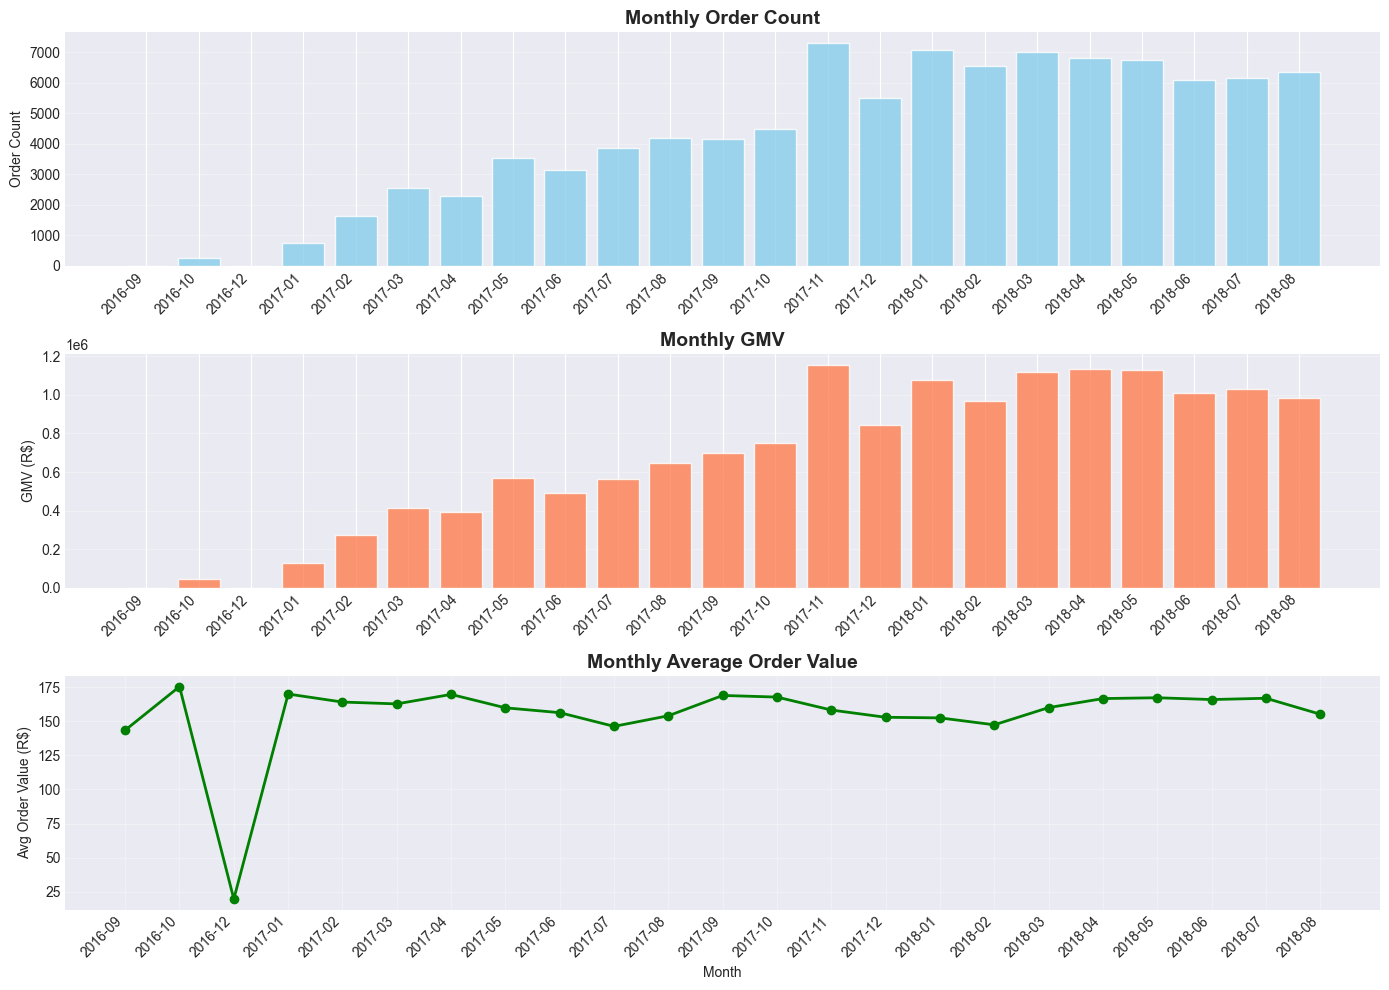

In [13]:
# Plot monthly order count, GMV, and average order value

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Monthly order count
axes[0].bar(range(len(df_monthly)), df_monthly['order_count'], color='skyblue', alpha=0.8)
axes[0].set_title('Monthly Order Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Order Count')
axes[0].set_xticks(range(len(df_monthly)))
axes[0].set_xticklabels(df_monthly['year_month'].dt.strftime('%Y-%m'), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Monthly GMV
axes[1].bar(range(len(df_monthly)), df_monthly['gmv'], color='coral', alpha=0.8)
axes[1].set_title('Monthly GMV', fontsize=14, fontweight='bold')
axes[1].set_ylabel('GMV (R$)')
axes[1].set_xticks(range(len(df_monthly)))
axes[1].set_xticklabels(df_monthly['year_month'].dt.strftime('%Y-%m'), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Monthly average order value
axes[2].plot(
    range(len(df_monthly)),
    df_monthly['avg_order_value'],
    marker='o',
    color='green',
    linewidth=2,
    markersize=6
)
axes[2].set_title('Monthly Average Order Value', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Avg Order Value (R$)')
axes[2].set_xlabel('Month')
axes[2].set_xticks(range(len(df_monthly)))
axes[2].set_xticklabels(df_monthly['year_month'].dt.strftime('%Y-%m'), rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Monthly descriptive statistics

print("Monthly Statistics:")
display(df_monthly[['order_count', 'gmv', 'avg_order_value']].describe())

Monthly Statistics:


,order_count,gmv,avg_order_value
count,23.000000,2.300000e+01,23.000000
mean,4194.695652,6.704249e+05,154.394168
std,2481.181398,3.951328e+05,30.572117
min,1.000000,1.962000e+01,19.620000
25%,2424.500000,4.025717e+05,153.475911
50%,4193.000000,7.010775e+05,160.016884
75%,6453.000000,1.019893e+06,167.064777
max,7289.000000,1.153364e+06,175.436453


### Monthly Trend Interpretation
The monthly trend shows a **strong growth trajectory** from **early 2017 to late 2017** in both order volume and GMV, suggesting rapid business expansion during this period. After the sharp peak around November 2017, the platform remained at a relatively high level in 2018, although growth became more stable rather than continuously increasing. Average order value is generally stable around **R$150–170**, which indicates that the rise in GMV was mainly driven by higher order volume rather than a major increase in spending per order. It should also be noted that a few early months contain extremely limited observations, so those points should be interpreted as incomplete periods rather than representative monthly behaviour.

## 2.3 Weekly Pattern Analysis
Weekly pattern analysis examines whether order activity is evenly distributed across the week or concentrated on specific weekdays.

This helps identify regular behavioural rhythms and provides operational insight for staffing, logistics, and campaign timing.

In [15]:
# Aggregate order count by day of week
# Use unique order_id to reflect true order volume

df_weekday = df_orders.groupby(['order_dayofweek', 'order_day_name']).agg(
    order_count=('order_id', 'nunique')
).reset_index()

df_weekday = df_weekday.sort_values('order_dayofweek')
df_weekday

,order_dayofweek,order_day_name,order_count
0,0,Monday,15701
1,1,Tuesday,15503
2,2,Wednesday,15076
3,3,Thursday,14323
4,4,Friday,13685
5,5,Saturday,10555
6,6,Sunday,11635


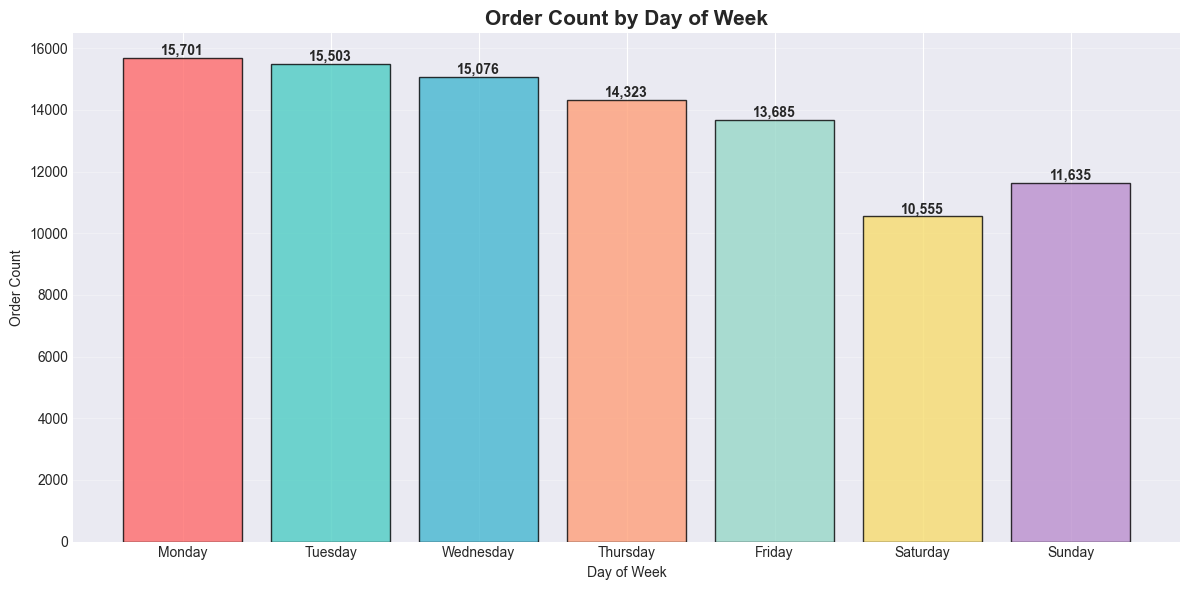

In [16]:
# Plot weekly order pattern

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    df_weekday['order_day_name'],
    df_weekday['order_count'],
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE'],
    alpha=0.8,
    edgecolor='black'
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Order Count by Day of Week', fontsize=15, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Order Count')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Weekly Pattern Interpretation
The weekly pattern shows that order activity is **concentrated on weekdays**, with **Monday** recording the highest volume, followed closely by **Tuesday** and **Wednesday**. In contrast, **weekend demand** is clearly lower, especially on **Saturday**, which suggests that platform usage is more **business-day oriented** than leisure-driven. This pattern implies a relatively regular weekly rhythm and indicates that operational pressure is likely to be higher at the **beginning of the week**.

## 2.4 Hourly Pattern Analysis
Hourly analysis focuses on intraday order behaviour and helps identify the most active and least active transaction periods.

This provides a finer view of customer behaviour and supports decisions on promotion timing and resource allocation.

In [17]:
# Aggregate order count by hour of day
# Use unique order_id to avoid item-level duplication

df_hourly = df_orders.groupby('order_hour').agg(
    order_count=('order_id', 'nunique')
).reset_index()

df_hourly

,order_hour,order_count
0,0,2321
1,1,1133
2,2,496
3,3,259
4,4,203
5,5,182
6,6,478
7,7,1199
8,8,2907
9,9,4647


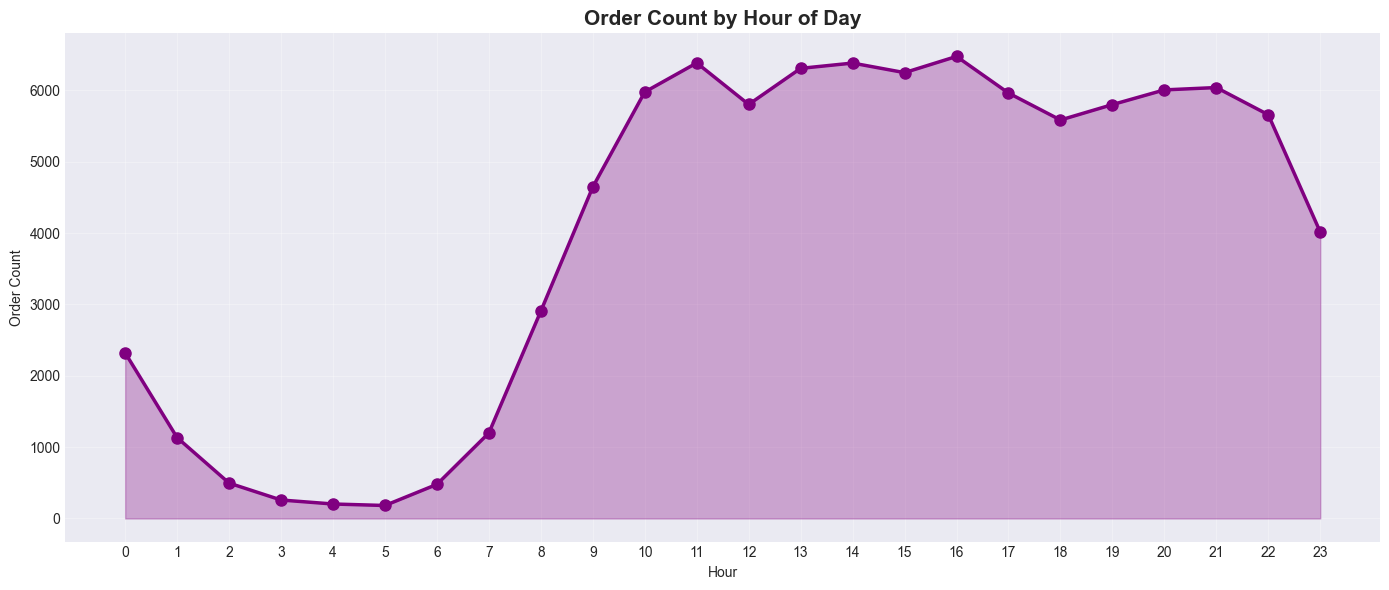

Peak hour: 16
Lowest hour: 5


In [18]:
# Plot hourly ordering pattern

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_hourly['order_hour'],
    df_hourly['order_count'],
    marker='o',
    color='purple',
    linewidth=2.5,
    markersize=8
)
ax.fill_between(df_hourly['order_hour'], df_hourly['order_count'], alpha=0.3, color='purple')

ax.set_title('Order Count by Hour of Day', fontsize=15, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Order Count')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Peak hour:", df_hourly.loc[df_hourly['order_count'].idxmax(), 'order_hour'])
print("Lowest hour:", df_hourly.loc[df_hourly['order_count'].idxmin(), 'order_hour'])

### Hourly Pattern Interpretation
The hourly pattern shows a clear **intraday cycle**. Order activity is very low during the **early morning hours**, rises rapidly after **08:00**, and remains high from **late morning to evening**, with the peak occurring at **16:00**. This suggests that customer purchasing behaviour is concentrated in **daytime and early evening** rather than overnight. The relatively elevated activity around **midnight** is notable and may reflect platform-specific behaviour or timestamp-related effects, so it should be interpreted with some caution.

### Chapter Reflection
This chapter shows that the platform has a clear **growth trend**, strong **weekday concentration**, and a relatively stable **intraday demand rhythm**. At the same time, some early monthly observations are **incomplete**, which means that temporal patterns should be interpreted with attention to **data coverage**. These descriptive findings provide the basis for the next stage of analysis, where **trend**, **seasonality**, and **irregular fluctuations** will be separated more formally.

## 3. Seasonal Decomposition
This section separates the daily time series into **trend**, **seasonal**, and **residual** components.

The purpose is to move from visual description to a more structured understanding of how the platform evolves over time.

## 3.1 Prepare Daily Time Series
Before decomposition, the daily order series needs to be converted into a regular time series indexed by date.

Because some calendar dates may be missing in the raw aggregation, `asfreq('D')` is used to create a complete daily sequence.

In [19]:
# Prepare daily order count time series
ts_daily = df_daily.set_index('order_date')["order_count"]

print(f"Original time series length: {len(ts_daily)}")
print(f"Original date range: {ts_daily.index.min()}to {ts_daily.index.max()}")

Original time series length: 612
Original date range: 2016-09-15 00:00:00to 2018-08-29 00:00:00


In [20]:
# Convert to regular daily frequency
# Fill missing calendar dates with 0 to keep time index continuous

ts_daily_complete = ts_daily.asfreq('D', fill_value=0)

print(f"Completed time series length: {len(ts_daily_complete)}")
print(f"Completed date range: {ts_daily_complete.index.min()} to {ts_daily_complete.index.max()}")

ts_daily_complete.head()

Completed time series length: 714
Completed date range: 2016-09-15 00:00:00 to 2018-08-29 00:00:00


order_date
2016-09-15    1
2016-09-16    0
2016-09-17    0
2016-09-18    0
2016-09-19    0
Freq: D, Name: order_count, dtype: int64

### Time Series Preparation Reflection
After converting the series to a regular daily frequency, the length increased from **612** to **714** days, which means that some calendar dates were missing in the original aggregation. Filling these dates with `0` is necessary to create a continuous daily time index for later decomposition and forecasting. At the same time, this also suggests that the raw business activity was not perfectly continuous in the early stage, so zero-filled periods should be interpreted as **no recorded orders** rather than confirmed absence of demand in a broader business sense.

## 3.2 Additive Seasonal Decomposition
The decomposition uses an **additive model**:

`Y(t) = Trend(t) + Seasonal(t) + Residual(t)`

This helps identify whether the observed series is mainly driven by long-term growth, repeating patterns, or irregular shocks.

In [21]:
# Perform additive seasonal decomposition
# Use period=30 as an approximate monthly cycle in daily data

decomposition = seasonal_decompose(
    ts_daily_complete,
    model='additive',
    period=30
)

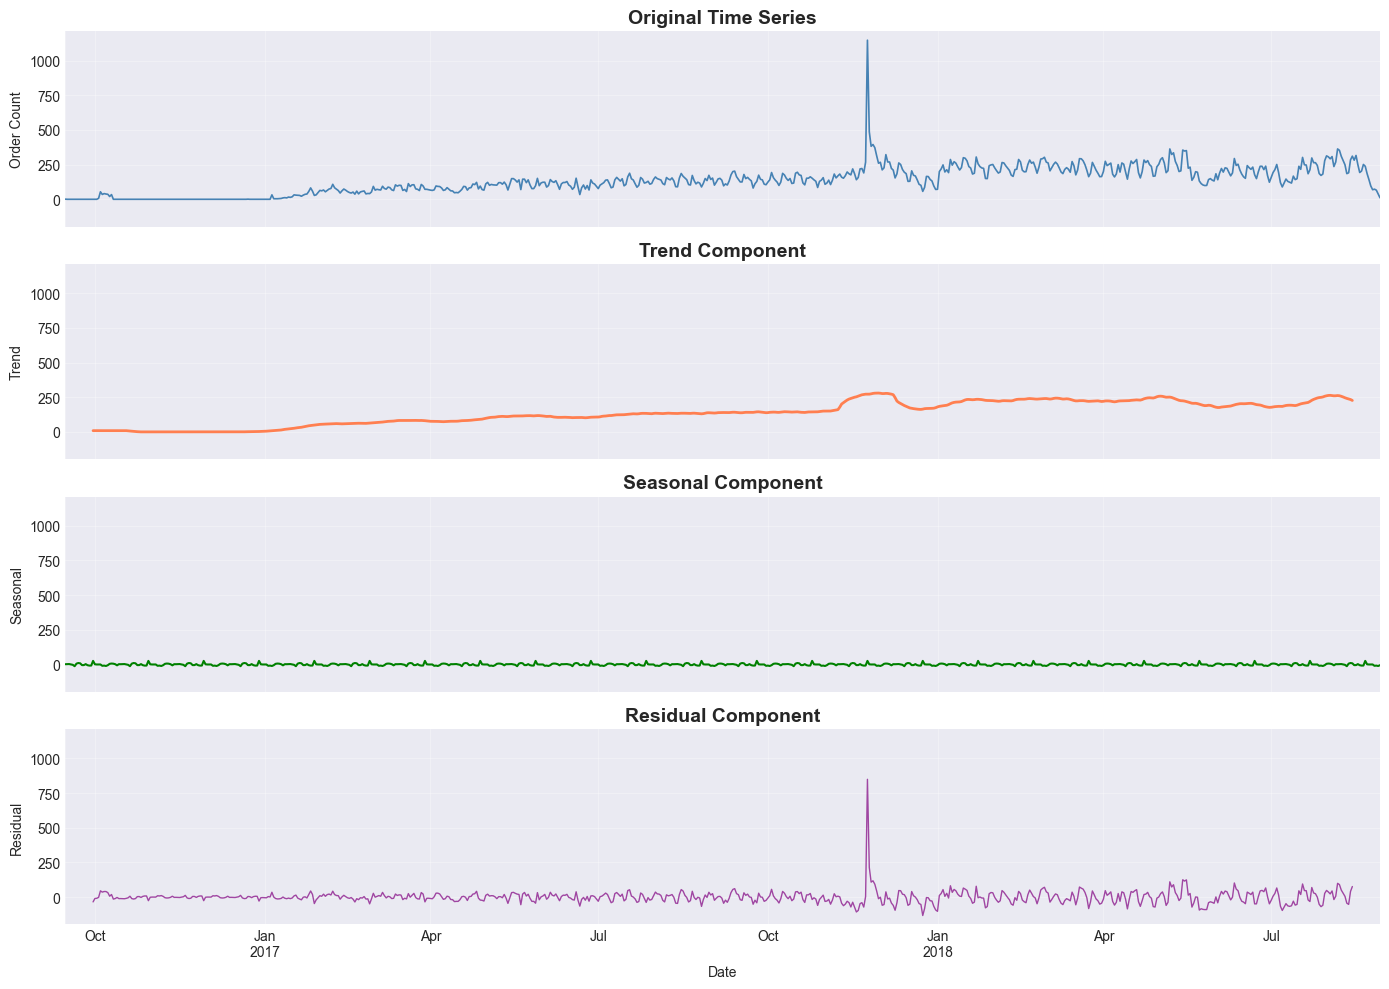

In [22]:
# Plot decomposition components

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True, sharey=True)

# Original series
decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=1.2)
axes[0].set_title('Original Time Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Order Count')
axes[0].grid(True, alpha=0.3)

# Trend component
decomposition.trend.plot(ax=axes[1], color='coral', linewidth=2)
axes[1].set_title('Trend Component', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Seasonal component
decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=1.5)
axes[2].set_title('Seasonal Component', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# Residual component
decomposition.resid.plot(ax=axes[3], color='purple', linewidth=1, alpha=0.7)
axes[3].set_title('Residual Component', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Seasonal Decomposition Interpretation
The decomposition result shows that the daily order series is driven mainly by a **rising trend component**, which is consistent with the growth pattern observed in the previous chapter. The **seasonal component** appears relatively modest compared with the overall level of the series, suggesting that long-term business expansion is stronger than short-cycle repetition at this stage. In contrast, the **residual component** contains a very prominent spike around late 2017, indicating that this surge is more likely an **irregular event or anomaly** rather than a normal seasonal fluctuation.

## 3.3 Stationarity Test
Before building forecasting models, it is important to examine whether the series is **stationary**.

Here, the **ADF test** is used on both the original series and the first-order differenced series.

In [24]:
# Define ADF test function
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    """
    Perform Augmented Dickey-Fuller test
    H0: The series has a unit root (non-stationary)
    H1: The series is stationary
    """
    result = adfuller(series.dropna(), autolag='AIC')

    print(f"ADF Test Results for {title}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")

    if result[1] <= 0.05:
        print(f"  ✓ Reject H0: The series is STATIONARY")
    else:
        print(f"  ✗ Fail to reject H0: The series is NON-STATIONARY")
    print()

In [26]:
# ADF test on original series
adf_test(ts_daily_complete, 'Original Series')

ADF Test Results for Original Series:
  ADF Statistic: -2.4588
  p-value: 0.1258
  Critical Values:
    1%: -3.4397
    5%: -2.8657
    10%: -2.5690
  ✗ Fail to reject H0: The series is NON-STATIONARY



In [27]:
# First-order differencing
ts_diff = ts_daily_complete.diff().dropna()

# ADF test on differenced series
adf_test(ts_diff, '1st Order Differenced Series')

ADF Test Results for 1st Order Differenced Series:
  ADF Statistic: -6.5542
  p-value: 0.0000
  Critical Values:
    1%: -3.4398
    5%: -2.8657
    10%: -2.5690
  ✓ Reject H0: The series is STATIONARY



### Stationarity Test Interpretation
The **ADF test** shows that the original series is **non-stationary**, with a `p-value` of **0.1258**, which means the null hypothesis cannot be rejected at the 5% significance level. This is consistent with the earlier decomposition result, where the series displayed a clear **upward trend** over time. After applying **first-order differencing**, the `p-value` drops to **0.0000**, indicating that the differenced series becomes **stationary**. This suggests that a differencing order of `d=1` is reasonable for later **ARIMA** modelling.

## 3.4 ACF and PACF Analysis
The **ACF** and **PACF** plots help examine the autocorrelation structure of the time series.

These plots provide useful reference for selecting the `p` and `q` parameters in later **ARIMA** modelling.

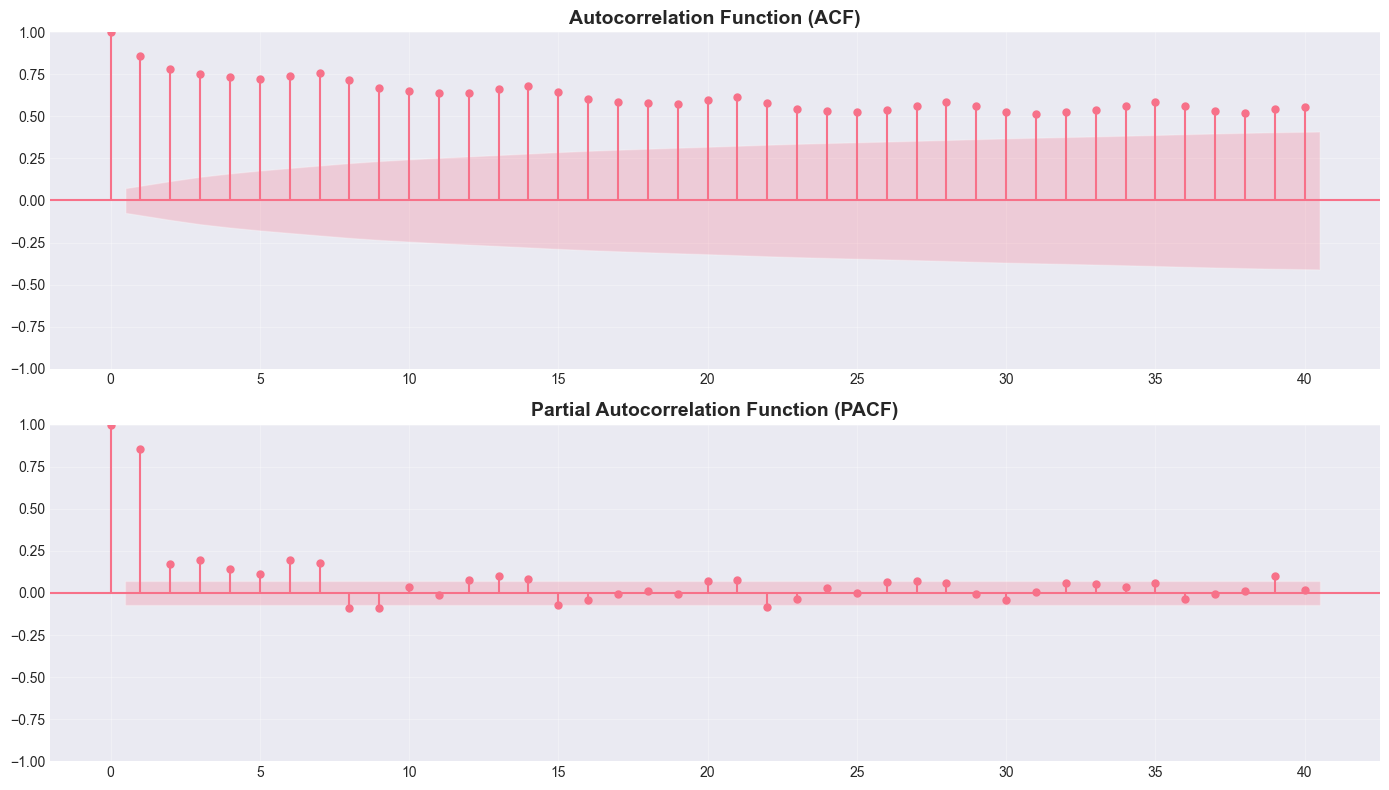

In [29]:
# Plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF
plot_acf(ts_daily_complete.dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(ts_daily_complete.dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ACF and PACF Interpretation
The **ACF** plot shows a **slow decay** across many lags, which is another sign that the original series contains strong persistence and is not stationary in its raw form. The **PACF** plot shows a very strong spike at **lag 1**, followed by smaller effects at later lags, suggesting that short-term dependence is important in the series. Taken together, these patterns support the use of a differenced model and provide an initial justification for testing simple **ARIMA** structures such as `ARIMA(1,1,1)` in the forecasting stage.

### Chapter Reflection
This chapter shows that the daily order series is shaped by a clear **trend component** and therefore is not stationary in its original form. After **first-order differencing**, the series becomes more suitable for time series modelling, while the **ACF** and **PACF** results suggest that short-lag autocorrelation remains important. These findings provide the statistical basis for the next stage, where abnormal fluctuations will be examined and forecasting models will be constructed more formally.m

## 4. Anomaly Detection
This section identifies unusual fluctuations in the daily order series that cannot be explained by the regular **trend** or **seasonal** pattern.

The goal is to distinguish normal business variation from potential **abnormal events**.

## 4.1 Detect Anomalies with the IQR Method
Here, anomalies are detected based on the `residual` component from seasonal decomposition.

Using the **IQR method** allows extreme deviations to be identified in a simple and interpretable way.

In [30]:
# Extract residual component
residuals = decomposition.resid.dropna()

print(f"Residual series length: {len(residuals)}")
residuals.head()

Residual series length: 684


order_date
2016-09-30   -34.700303
2016-10-01   -10.122042
2016-10-02    -8.772042
2016-10-03    -1.953202
2016-10-04    45.038827
Freq: D, Name: resid, dtype: float64

In [31]:
# Detect anomalies using IQR method

Q1 = residuals.quantile(0.25)
Q3 = residuals.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies = residuals[(residuals < lower_bound) | (residuals > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Detected anomaly points: {len(anomalies)}")
print(f"Anomaly rate: {len(anomalies) / len(residuals) * 100:.2f}%")

Q1: -18.78
Q3: 19.10
IQR: 37.87
Lower bound: -75.59
Upper bound: 75.91
Detected anomaly points: 33
Anomaly rate: 4.82%


In [32]:
# Display anomaly dates and residual values
anomalies.sort_values()

order_date
2017-12-24   -132.900303
2017-11-18   -107.263841
2018-01-01   -102.929289
2017-11-19    -96.600962
2018-07-07    -96.563347
2017-12-09    -94.930013
2018-05-23    -93.716970
2017-12-31    -92.656825
2018-05-26    -90.286535
2018-05-27    -89.961173
2018-05-25    -88.738709
2018-04-14    -85.219868
2018-05-24    -84.155375
2018-03-24    -83.016970
2017-12-25    -82.588709
2018-01-27    -77.644506
2018-08-14     76.043900
2018-01-22     78.045250
2018-01-08     81.719987
2018-05-09     89.133030
2018-08-07     89.883030
2017-11-28     92.738827
2018-07-18     94.350553
2018-08-06     99.153320
2018-06-11    101.654769
2017-11-26    107.761291
2018-05-07    109.969262
2018-05-15    115.330856
2017-11-27    117.396798
2018-05-16    124.060567
2018-05-14    124.813465
2017-11-25    213.661291
2017-11-24    849.049697
Name: resid, dtype: float64

### Anomaly Detection Interpretation
Using the **IQR method** on the `residual` component, a total of **33 anomaly points** were detected out of **684** valid residual observations, corresponding to an anomaly rate of **4.82%**. This suggests that most daily fluctuations can still be explained by the regular **trend** and **seasonal** structure, while a relatively small subset of days shows unusually large deviations. The most extreme anomalies are mainly concentrated around **late 2017** and several periods in **2018**, indicating that abnormal movements are not random noise but are linked to specific time windows of unusual business activity.

## 4.2 Visualise Anomalies on the Original Series
After identifying anomalous `residual` points, the next step is to map them back to the original daily order series.

This helps assess whether the anomalies correspond to isolated spikes, sudden drops, or clusters of unusual activity.

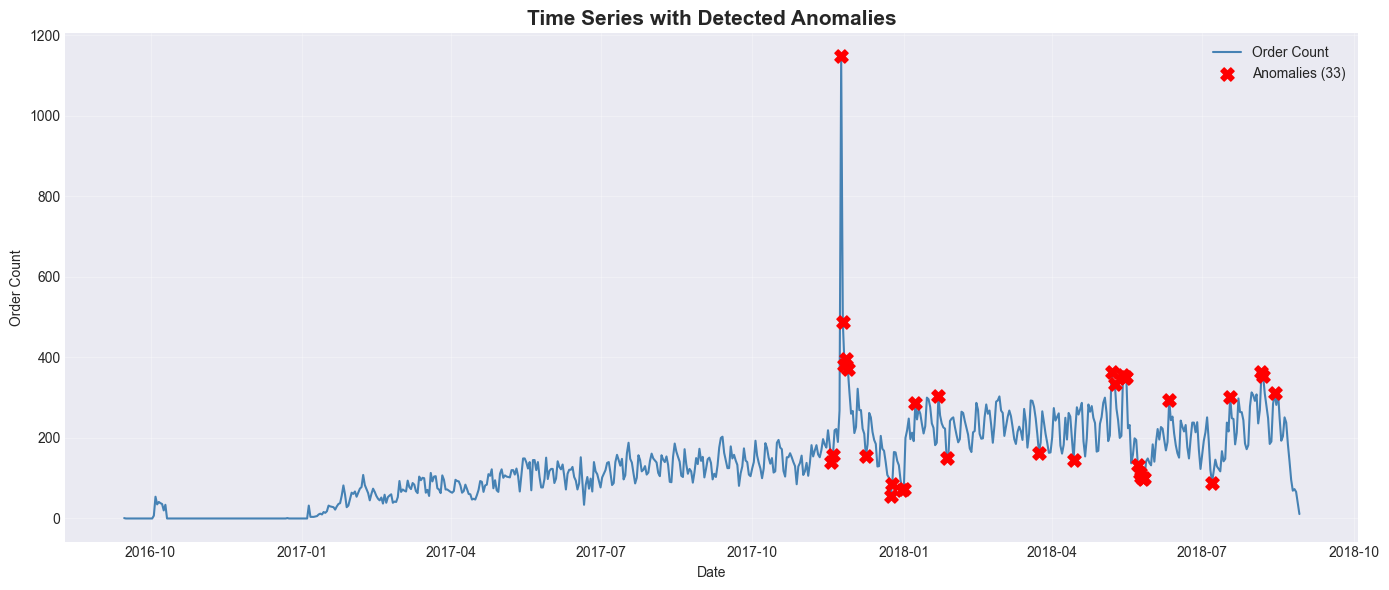

In [33]:
# Plot anomalies on the original daily series

fig, ax = plt.subplots(figsize=(14, 6))

# Original daily order series
ax.plot(
    ts_daily_complete.index,
    ts_daily_complete.values,
    color='steelblue',
    linewidth=1.5,
    label='Order Count'
)

# Anomaly points
anomaly_dates = anomalies.index
anomaly_values = ts_daily_complete.loc[anomaly_dates]

ax.scatter(
    anomaly_dates,
    anomaly_values,
    color='red',
    s=90,
    marker='X',
    zorder=5,
    label=f'Anomalies ({len(anomalies)})'
)

ax.set_title('Time Series with Detected Anomalies', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Order Count')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Anomaly Visualisation Interpretation
The anomaly visualisation shows that the detected points are clustered rather than evenly distributed across the full time series. The most prominent anomaly appears around **late 2017**, where the daily order count spikes sharply above the surrounding baseline, suggesting a major **event-driven surge** rather than normal variation. In addition, several anomaly clusters appear in early and mid **2018**, including both unusually high and unusually low observations, which may reflect promotional events, holiday effects, operational disruptions, or short-term demand shocks. This pattern indicates that the business series contains not only long-term growth, but also intermittent periods of **abnormal volatility** that should be considered in later forecasting and business interpretation.m

## 5. Category-Based Temporal Comparison
This section compares temporal patterns across major product categories.

The purpose is to examine whether different categories follow similar **time dynamics** or show distinct **demand rhythms**.

## 5.1 Identify Top Categories
To keep the comparison focused and interpretable, the analysis selects the **top 5 categories** by order volume.

Since category labels contain some missing values, this part uses only records with valid `category_name_english`.

In [34]:
# Create category-only dataset if not already created
df_orders_category = df_orders[df_orders['category_name_english'].notna()].copy()

print(f"Full dataset size: {len(df_orders):,}")
print(f"Category analysis dataset size: {len(df_orders_category):,}")
print(f"Removed missing-category records: {len(df_orders) - len(df_orders_category):,}")

Full dataset size: 110,197
Category analysis dataset size: 108,660
Removed missing-category records: 1,537


In [35]:
# Identify top 5 categories by unique order count
top_categories = (
    df_orders_category.groupby('category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Top 5 categories:")
for i, cat in enumerate(top_categories, 1):
    count = df_orders_category[df_orders_category['category_name_english'] == cat]['order_id'].nunique()
    print(f"{i}. {cat}: {count:,} orders")

Top 5 categories:
1. cama_mesa_banho: 9,272 orders
2. beleza_saude: 8,647 orders
3. esporte_lazer: 7,530 orders
4. informatica_acessorios: 6,530 orders
5. moveis_decoracao: 6,307 orders


### Top Category Reflection
After removing records with missing `category_name_english`, the category analysis dataset retains **108,660** observations out of **110,197**, which means the exclusion affects only a **small proportion** of the full dataset and does not materially change the overall category structure. The **top 5 categories** are `cama_mesa_banho`, `beleza_saude`, `esporte_lazer`, `informatica_acessorios`, and `moveis_decoracao`, showing that demand is concentrated in a small set of major product groups. This suggests that subsequent category-based time analysis can focus on these leading categories without losing the main pattern of platform demand.

## 5.2 Monthly Trend by Top Categories
After identifying the major categories, the next step is to compare their **monthly order trends**.

This helps assess whether category growth is broadly synchronized or whether some categories follow different **temporal trajectories**.

In [36]:
# Monthly order trend for top categories
df_category_monthly = (
    df_orders_category[df_orders_category['category_name_english'].isin(top_categories)]
    .groupby(['order_year', 'order_month', 'category_name_english'])
    .agg(order_count=('order_id', 'nunique'))
    .reset_index()
)

df_category_monthly['year_month'] = pd.to_datetime(
    df_category_monthly[['order_year', 'order_month']]
    .rename(columns={'order_year': 'year', 'order_month': 'month'})
    .assign(day=1)
)

print(df_category_monthly.shape)
df_category_monthly.head()

(106, 5)


,order_year,order_month,category_name_english,order_count,year_month
0,2016,9,beleza_saude,1,2016-09-01
1,2016,10,beleza_saude,36,2016-10-01
2,2016,10,cama_mesa_banho,5,2016-10-01
3,2016,10,esporte_lazer,17,2016-10-01
4,2016,10,informatica_acessorios,12,2016-10-01


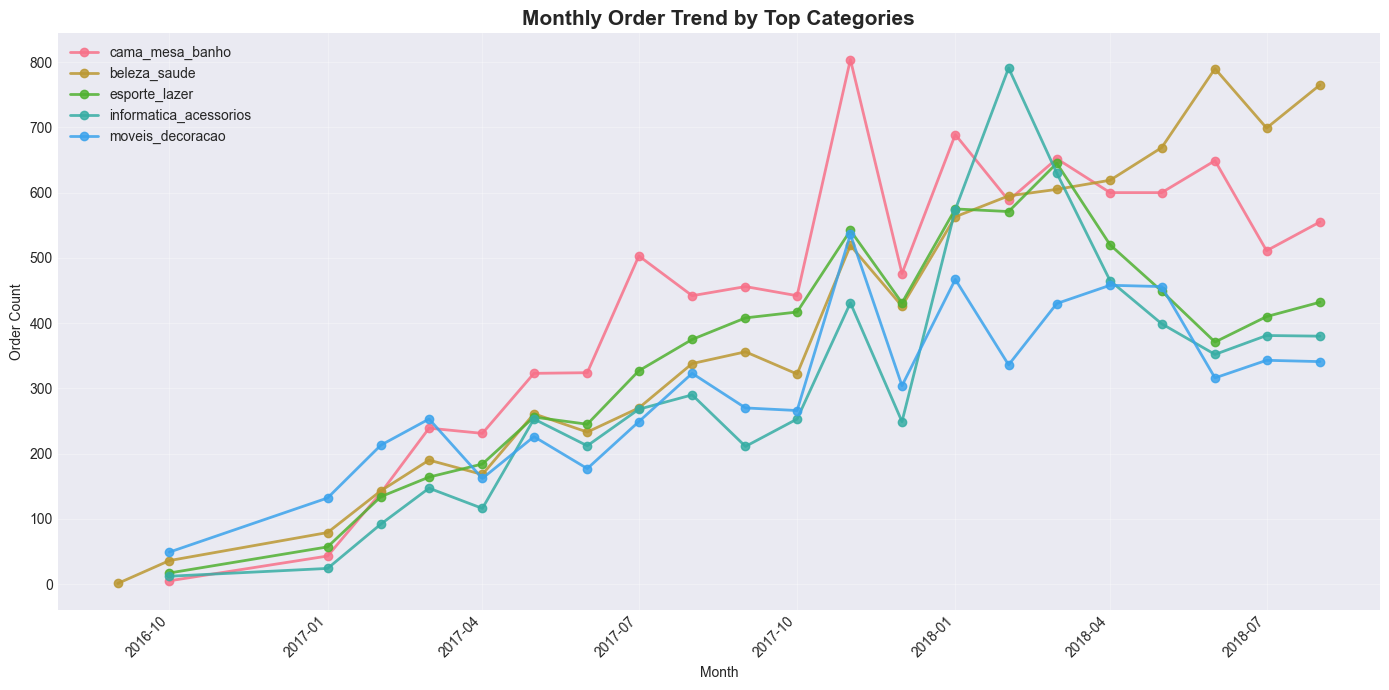

In [37]:
# Plot monthly order trend by top categories

fig, ax = plt.subplots(figsize=(14, 7))

for category in top_categories:
    cat_data = df_category_monthly[df_category_monthly['category_name_english'] == category]
    ax.plot(
        cat_data['year_month'],
        cat_data['order_count'],
        marker='o',
        linewidth=2,
        label=category,
        alpha=0.85
    )

ax.set_title('Monthly Order Trend by Top Categories', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Order Count')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Category Monthly Trend Interpretation
The monthly category trends show that all **top 5 categories** generally follow the platform’s overall growth path, with clear expansion from 2017 into 2018, which suggests that category demand was broadly aligned with the overall business cycle. However, the categories do not grow at the same speed or with the same volatility. For example, `cama_mesa_banho` shows a very sharp spike around late 2017, while `beleza_saude` becomes especially strong in the later period and reaches the highest level in several months of 2018. In contrast, categories such as `moveis_decoracao` and `informatica_acessorios` remain important but operate at a relatively lower volume level. This indicates that although the major categories share a common upward direction, they still exhibit **different temporal trajectories** and may respond differently to promotions, seasonality, or changes in customer demand.

## 5.3 Weekly Pattern by Top Categories
After comparing monthly category trends, the next step is to examine whether the major categories also differ in their **within-week demand pattern**.

This helps assess whether weekday concentration is consistent across categories or whether some categories follow different **weekly rhythms**.

In [38]:
# Weekly order pattern by top categories
df_category_weekday = (
    df_orders_category[df_orders_category['category_name_english'].isin(top_categories)]
    .groupby(['order_dayofweek', 'order_day_name', 'category_name_english'])
    .agg(order_count=('order_id', 'nunique'))
    .reset_index()
)

print(df_category_weekday.shape)
df_category_weekday.head()

(35, 4)


,order_dayofweek,order_day_name,category_name_english,order_count
0,0,Monday,beleza_saude,1390
1,0,Monday,cama_mesa_banho,1468
2,0,Monday,esporte_lazer,1254
3,0,Monday,informatica_acessorios,1155
4,0,Monday,moveis_decoracao,1009


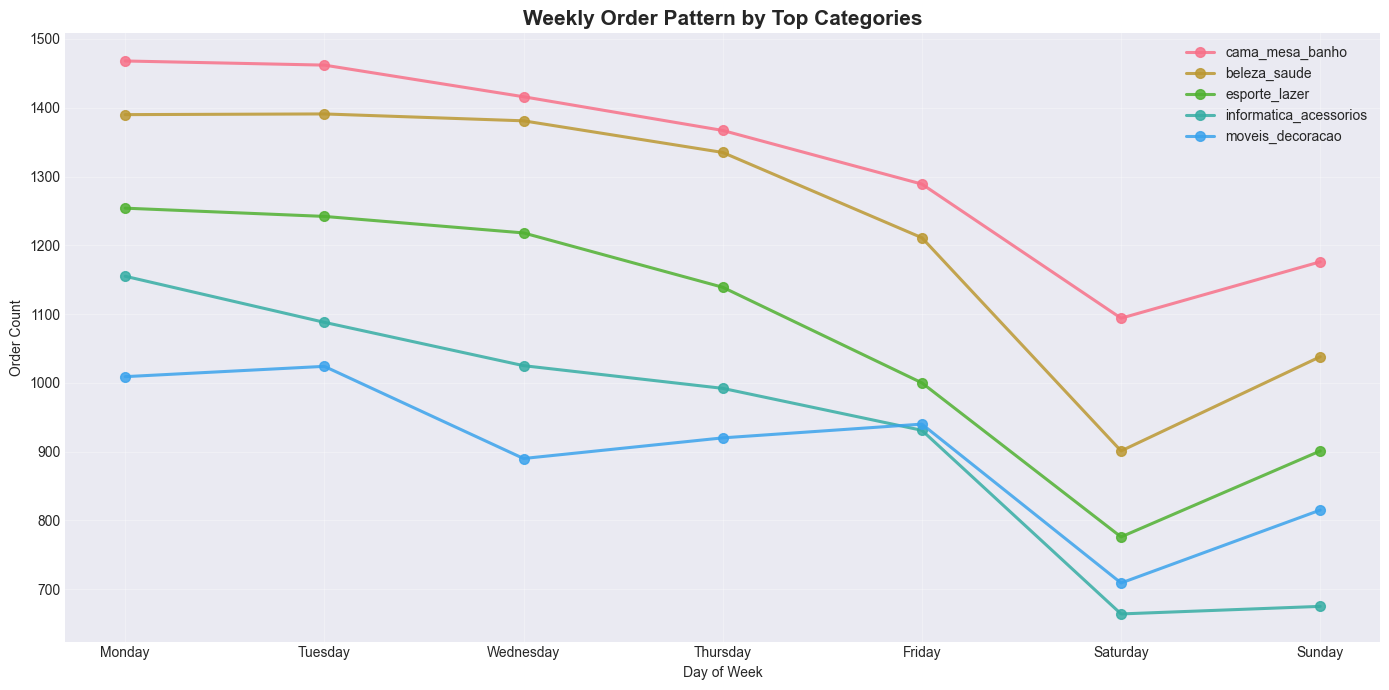

In [39]:
# Plot weekly pattern by top categories

fig, ax = plt.subplots(figsize=(14, 7))

for category in top_categories:
    cat_data = df_category_weekday[df_category_weekday['category_name_english'] == category]
    cat_data = cat_data.sort_values('order_dayofweek')

    ax.plot(
        cat_data['order_day_name'],
        cat_data['order_count'],
        marker='o',
        linewidth=2.2,
        markersize=7,
        label=category,
        alpha=0.85
    )

ax.set_title('Weekly Order Pattern by Top Categories', fontsize=15, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Order Count')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Category Weekly Pattern Interpretation
The weekly category comparison shows that all **top 5 categories** follow a broadly similar **weekday-driven pattern**, with demand generally highest at the beginning of the week and lowest on **Saturday**. This suggests that the weekly rhythm observed at the platform level is not caused by a single category, but is shared across multiple major product groups. At the same time, the size of the decline differs across categories. For example, `informatica_acessorios` and `esporte_lazer` show a relatively sharper weekend drop, while `cama_mesa_banho` remains the most stable and highest-volume category throughout the week. This indicates that the categories share a common weekly structure, but still differ in the **strength of weekday concentration**.

## 6. Forecasting Models
This section evaluates several forecasting approaches for the daily order series.

The analysis starts with a simple **train-test split** and a **baseline model** before moving to more advanced methods.

## 6.1 Train-Test Split
To evaluate forecasting performance, the daily series is divided into a **training set** and a **test set**.

The last **30 days** are reserved as the test period, while all earlier observations are used for model fitting.

In [40]:
# Split data into train and test sets
# Use the last 30 days as the test period

train_size = len(ts_daily_complete) - 30
train = ts_daily_complete[:train_size]
test = ts_daily_complete[train_size:]

print(f"Train set length: {len(train)} days")
print(f"Train date range: {train.index.min()} to {train.index.max()}")
print(f"Test set length: {len(test)} days")
print(f"Test date range: {test.index.min()} to {test.index.max()}")

Train set length: 684 days
Train date range: 2016-09-15 00:00:00 to 2018-07-30 00:00:00
Test set length: 30 days
Test date range: 2018-07-31 00:00:00 to 2018-08-29 00:00:00


### Train-Test Split Reflection
The daily series is divided into **684 training days** and **30 test days**, with the test period covering **2018-07-31** to **2018-08-29**. This split preserves most of the historical data for model fitting while keeping a recent window for out-of-sample evaluation. Using the last **30 days** as the test set is also reasonable from a business perspective, since short-term forecasting performance is especially relevant for operational planning.
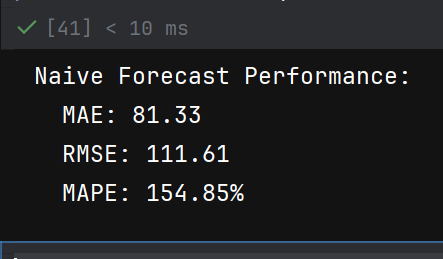

## 6.2 Baseline Model - Naive Forecast
Before fitting more complex models, a simple **Naive Forecast** is used as the baseline.

This method assumes that future values will remain equal to the **last observed value** in the training series.

In [41]:
# Naive forecast using the last observed training value

naive_forecast = [train.iloc[-1]] * len(test)

mae_naive = mean_absolute_error(test, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test, naive_forecast))
mape_naive = np.mean(np.abs((test - naive_forecast) / test.replace(0, np.nan))) * 100

print("Naive Forecast Performance:")
print(f"  MAE: {mae_naive:.2f}")
print(f"  RMSE: {rmse_naive:.2f}")
print(f"  MAPE: {mape_naive:.2f}%")

Naive Forecast Performance:
  MAE: 81.33
  RMSE: 111.61
  MAPE: 154.85%


### Naive Forecast Interpretation
The **Naive Forecast** provides a simple baseline by assuming that all future daily orders remain equal to the **last observed training value**. Its performance shows relatively large errors, especially the very high `MAPE` of **154.85%**, which suggests that the final 30-day period contains substantial variation that cannot be captured by a constant forecast. This means the baseline model is useful as a reference point, but more flexible time series models are needed to better reflect the changing demand pattern.

## 6.3 Moving Average Model
The next benchmark uses a simple **Moving Average** forecast.

Here, the forecast is based on the average of the most recent **7 days** in the training set, which helps smooth short-term noise.

In [42]:
# Moving Average forecast using the last 7 training days

window = 7
ma_forecast_value = train.rolling(window=window).mean().iloc[-1]
ma_forecast = [ma_forecast_value] * len(test)

mae_ma = mean_absolute_error(test, ma_forecast)
rmse_ma = np.sqrt(mean_squared_error(test, ma_forecast))
mape_ma = np.mean(np.abs((test - ma_forecast) / test.replace(0, np.nan))) * 100

print(f"Moving Average (window={window}) Performance:")
print(f"  MAE: {mae_ma:.2f}")
print(f"  RMSE: {rmse_ma:.2f}")
print(f"  MAPE: {mape_ma:.2f}%")

Moving Average (window=7) Performance:
  MAE: 79.77
  RMSE: 96.75
  MAPE: 126.26%


### Moving Average Interpretation
Compared with the **Naive Forecast**, the **Moving Average** model shows a modest improvement across all three metrics, with lower `MAE`, `RMSE`, and `MAPE`. This suggests that using the recent **7-day average** helps smooth short-term noise and provides a more stable baseline for prediction. However, the error level is still relatively high, which means that a simple moving average is still too limited to capture the more complex **time dependence** in the daily order series.

## 6.4 ARIMA Model
The **ARIMA** model is used to capture autoregressive structure, differencing, and moving-average effects in the daily order series.

Based on the earlier **ADF**, **ACF**, and **PACF** results, `ARIMA(1,1,1)` is used here as an initial specification.

In [43]:
# Fit ARIMA(1,1,1) model

arima_model = ARIMA(train, order=(1, 1, 1))
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:            order_count   No. Observations:                  684
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3606.687
Date:                Fri, 03 Apr 2026   AIC                           7219.374
Time:                        23:07:17   BIC                           7232.953
Sample:                    09-15-2016   HQIC                          7224.629
                         - 07-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4504      0.031     14.647      0.000       0.390       0.511
ma.L1         -0.9032      0.025    -35.974      0.000      -0.952      -0.854
sigma2      2257.8219     15.770    143.173      0.0

In [44]:
# Forecast with ARIMA

arima_forecast = arima_fitted.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
mape_arima = np.mean(np.abs((test - arima_forecast) / test.replace(0, np.nan))) * 100

print("ARIMA(1,1,1) Performance:")
print(f"  MAE: {mae_arima:.2f}")
print(f"  RMSE: {rmse_arima:.2f}")
print(f"  MAPE: {mape_arima:.2f}%")

ARIMA(1,1,1) Performance:
  MAE: 79.44
  RMSE: 95.38
  MAPE: 122.88%


### ARIMA Interpretation
The `ARIMA(1,1,1)` model performs slightly better than both the **Naive Forecast** and the **Moving Average** model, achieving the lowest `MAE`, `RMSE`, and `MAPE` so far. This suggests that incorporating **autoregressive**, **differencing**, and **moving average** components improves the model’s ability to capture the short-term structure of the series. In the model summary, both `ar.L1` and `ma.L1` are statistically significant, which indicates that lag-based dependence is meaningful in the daily order data. However, the residual diagnostics also show strong **non-normality** and **heteroskedasticity**, implying that although `ARIMA(1,1,1)` is a reasonable starting model, it may still struggle to fully capture the irregular volatility and extreme fluctuations observed earlier in the series.

## 6.5 Exponential Smoothing Model
The **Exponential Smoothing** model is used to capture level, trend, and seasonal structure in the daily series.

Here, an additive **trend** and additive **seasonality** are specified with `seasonal_periods=30`.

In [45]:
# Fit Exponential Smoothing model

es_model = ExponentialSmoothing(
    train,
    seasonal_periods=30,
    trend='add',
    seasonal='add'
)

es_fitted = es_model.fit()

# Forecast
es_forecast = es_fitted.forecast(steps=len(test))

mae_es = mean_absolute_error(test, es_forecast)
rmse_es = np.sqrt(mean_squared_error(test, es_forecast))
mape_es = np.mean(np.abs((test - es_forecast) / test.replace(0, np.nan))) * 100

print("Exponential Smoothing Performance:")
print(f"  MAE: {mae_es:.2f}")
print(f"  RMSE: {rmse_es:.2f}")
print(f"  MAPE: {mape_es:.2f}%")

Exponential Smoothing Performance:
  MAE: 79.02
  RMSE: 98.85
  MAPE: 132.94%


### Exponential Smoothing Interpretation
The **Exponential Smoothing** model achieves the **lowest `MAE`** among all models tested so far, which means it performs relatively well in terms of average absolute error. This suggests that modelling the series with explicit **level**, **trend**, and **seasonal** components helps capture the general demand pattern more effectively than simpler baseline methods. However, its `RMSE` and `MAPE` are still relatively high, which indicates that the model remains sensitive to large deviations and does not fully absorb the abnormal volatility identified earlier.

## 6.6 Prophet Model
The **Prophet** model is designed to handle trend changes, seasonality, and flexible time series patterns.

Here, the model includes **yearly** and **weekly** seasonality and is fitted on the training portion of the daily series.

In [46]:
# Prepare training data for Prophet
df_prophet = train.reset_index()
df_prophet.columns = ['ds', 'y']

# Fit Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

prophet_model.fit(df_prophet)

23:13:20 - cmdstanpy - INFO - Chain [1] start processing
23:13:21 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
# Forecast with Prophet
future = prophet_model.make_future_dataframe(periods=len(test), freq='D')
prophet_forecast = prophet_model.predict(future)

# Extract forecast for test period
prophet_test_forecast = prophet_forecast.iloc[-len(test):]['yhat'].values

mae_prophet = mean_absolute_error(test, prophet_test_forecast)
rmse_prophet = np.sqrt(mean_squared_error(test, prophet_test_forecast))
mape_prophet = np.mean(np.abs((test - prophet_test_forecast) / test.replace(0, np.nan))) * 100

print("Prophet Performance:")
print(f"  MAE: {mae_prophet:.2f}")
print(f"  RMSE: {rmse_prophet:.2f}")
print(f"  MAPE: {mape_prophet:.2f}%")

Prophet Performance:
  MAE: 80.36
  RMSE: 90.31
  MAPE: 108.37%


### Prophet Interpretation
The **Prophet** model produces the **lowest `RMSE`** and the **lowest `MAPE`** among all evaluated models, suggesting that it provides the most balanced overall fit for the test period. This indicates that Prophet is better able to handle the series’ changing **trend** and recurring **seasonal structure** than the previous models. Although its `MAE` is slightly higher than that of **Exponential Smoothing**, its stronger performance on `RMSE` and `MAPE` suggests that it is more robust when forecasting periods with larger fluctuations.

## 7. Model Comparison and Evaluation
This section compares the forecasting performance of all tested models.

The goal is to identify which model provides the most reliable prediction for the daily order series.

## 7.1 Performance Comparison Table
The model comparison table summarises forecasting accuracy using `MAE`, `RMSE`, and `MAPE`.

Comparing multiple metrics helps avoid relying on a single measure of model quality.

In [48]:
# Create model comparison table

model_comparison = pd.DataFrame({
    'Model': ['Naive', 'Moving Average', 'ARIMA(1,1,1)', 'Exponential Smoothing', 'Prophet'],
    'MAE': [mae_naive, mae_ma, mae_arima, mae_es, mae_prophet],
    'RMSE': [rmse_naive, rmse_ma, rmse_arima, rmse_es, rmse_prophet],
    'MAPE (%)': [mape_naive, mape_ma, mape_arima, mape_es, mape_prophet]
})

model_comparison = model_comparison.sort_values('MAE')

print("Model Performance Comparison:")
display(model_comparison)

print(f"Best model by MAE: {model_comparison.iloc[0]['Model']}")

Model Performance Comparison:


,Model,MAE,RMSE,MAPE (%)
3,Exponential Smoothing,79.022727,98.847195,132.939099
2,"ARIMA(1,1,1)",79.440568,95.375617,122.884393
1,Moving Average,79.771429,96.745771,126.259409
4,Prophet,80.360398,90.306919,108.365876
0,Naive,81.333333,111.605257,154.850771


Best model by MAE: Exponential Smoothing


### Model Comparison Interpretation
The comparison table shows that **no single model is best on every metric**. **Exponential Smoothing** achieves the lowest `MAE`, which means it performs best in terms of average absolute error, while **Prophet** achieves the lowest `RMSE` and `MAPE`, suggesting stronger overall performance when larger deviations and relative error are taken into account. `ARIMA(1,1,1)` also performs competitively and improves on the simpler benchmark models. Overall, the results indicate that the more structured time series models clearly outperform the **Naive Forecast**, but the final model choice should depend on which error metric is considered most important for the business task.

## 7.2 Forecast Comparison Plot
In addition to the metric table, it is useful to compare the forecast trajectories visually.

This helps assess how closely each model follows the **actual test series** over time.

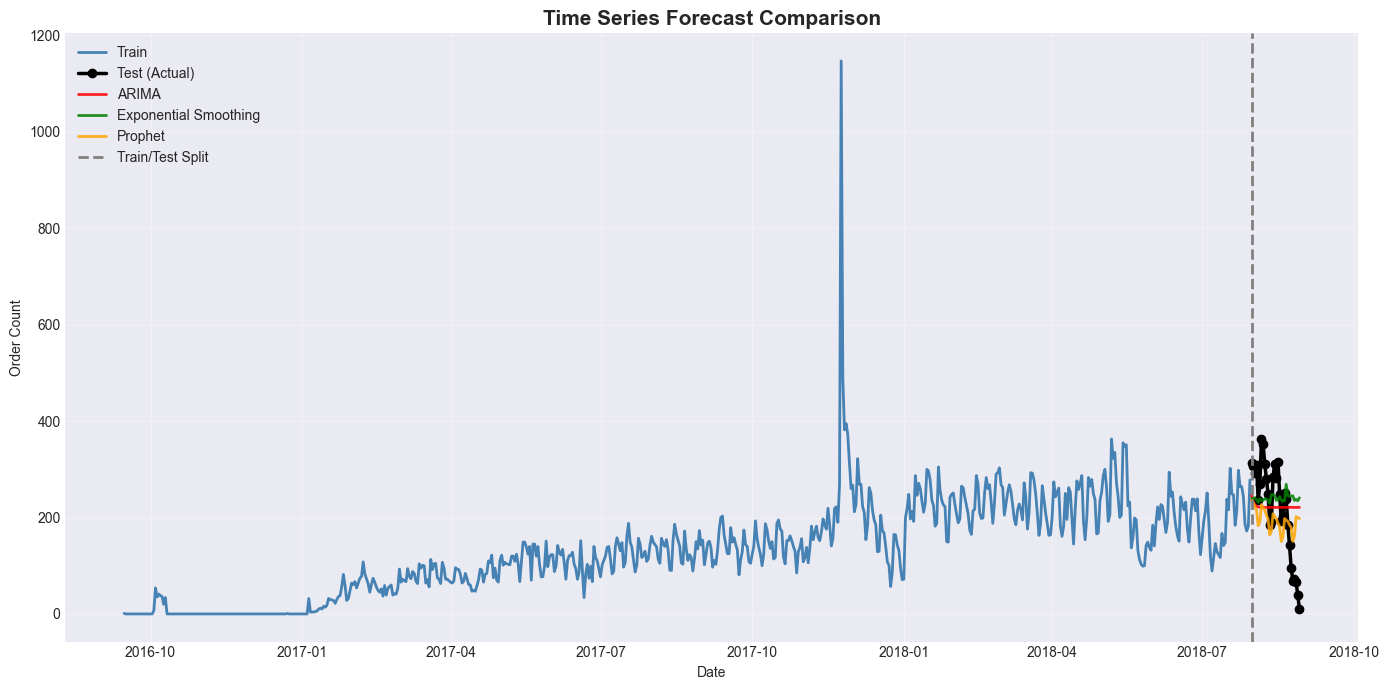

In [49]:
# Plot forecast comparison

fig, ax = plt.subplots(figsize=(14, 7))

# Train and test series
ax.plot(train.index, train.values, label='Train', color='steelblue', linewidth=2)
ax.plot(test.index, test.values, label='Test (Actual)', color='black', linewidth=2.5, marker='o')

# Model forecasts
ax.plot(test.index, arima_forecast, label='ARIMA', color='red', linewidth=2, alpha=0.85)
ax.plot(test.index, es_forecast, label='Exponential Smoothing', color='green', linewidth=2, alpha=0.85)
ax.plot(test.index, prophet_test_forecast, label='Prophet', color='orange', linewidth=2, alpha=0.85)

# Train-test split line
ax.axvline(x=test.index[0], color='gray', linestyle='--', linewidth=2, label='Train/Test Split')

ax.set_title('Time Series Forecast Comparison', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Order Count')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Forecast Comparison Interpretation
The forecast comparison plot shows that all three advanced models generate a much smoother trajectory than the **actual test series**, which indicates that the final 30-day period contains substantial short-term fluctuation that is difficult to predict precisely. Among them, **Prophet** appears to track the general level of the test period more consistently, while **Exponential Smoothing** and **ARIMA** remain competitive but also smooth out local variation. A further point that should be noted is the sharp drop at the end of the **actual** series, which is likely influenced by incomplete end-period data rather than a true collapse in demand. This means the visual comparison should be interpreted with caution, especially for the final few observations.

## 7.3 Prophet Forecast with Confidence Interval
Since **Prophet** performs strongly on `RMSE` and `MAPE`, it is useful to examine its forecast structure in more detail.

The following plots show both the overall forecast with uncertainty bounds and the decomposed components learned by the model.

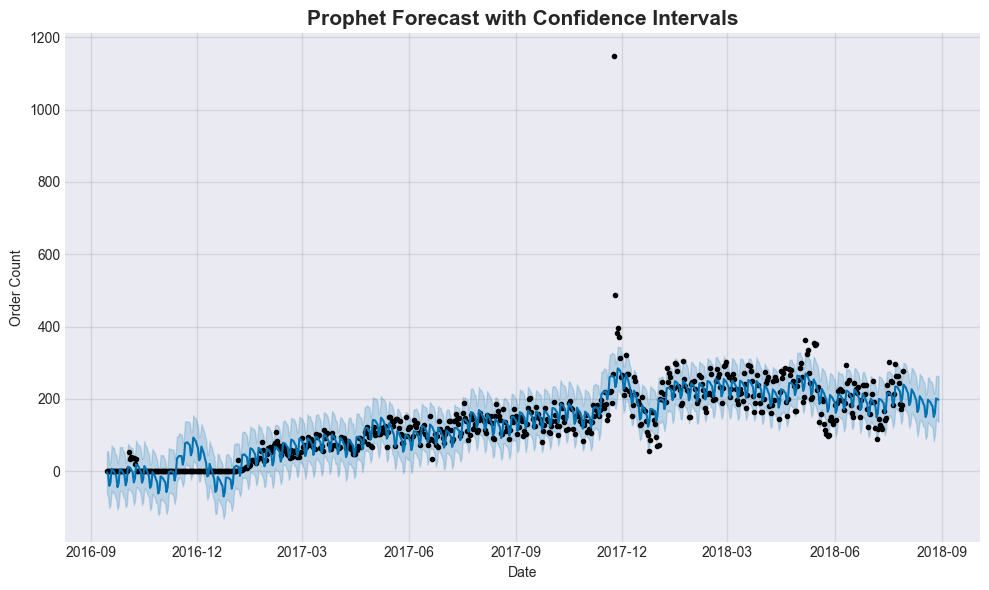

In [50]:
# Plot Prophet forecast with confidence intervals
fig = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast with Confidence Intervals', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Order Count')
plt.tight_layout()
plt.show()

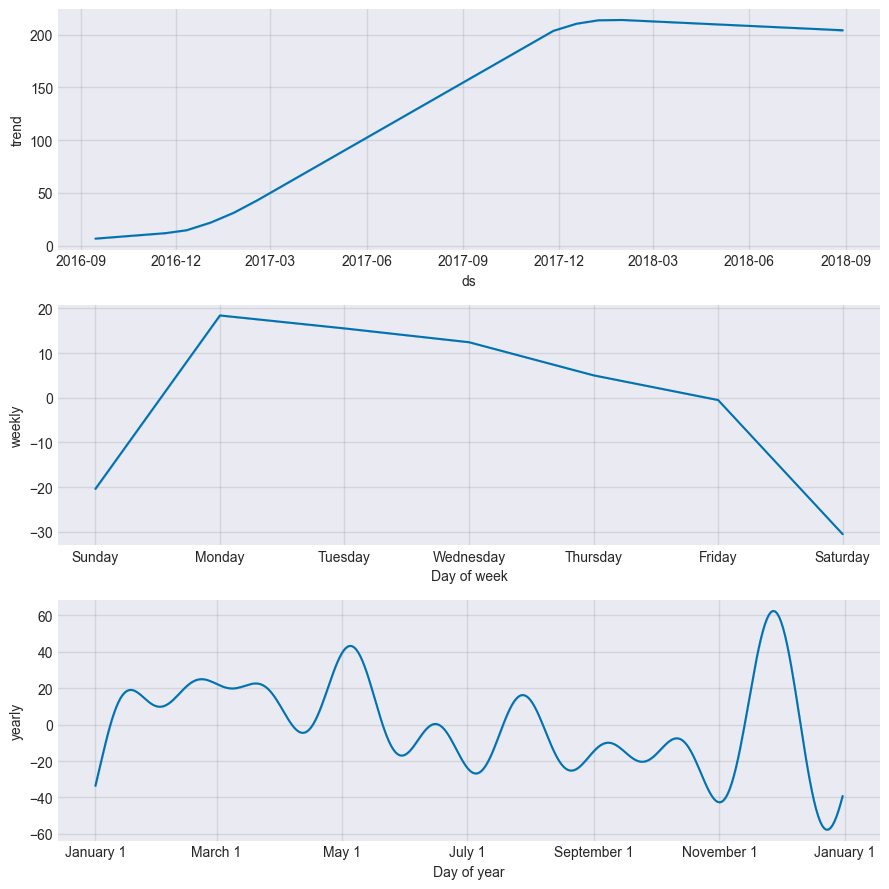

In [51]:
# Plot Prophet components
fig = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

### Prophet Forecast Interpretation
The **Prophet** forecast captures the platform’s overall **upward trend** reasonably well, especially the strong growth phase from **2017** to early **2018**. The shaded confidence interval shows that the model allows for uncertainty around the central forecast, but the very large spike around **late 2017** still lies far above the expected range, which confirms that this point is better interpreted as an **abnormal event** rather than a regular seasonal movement.

The component plots also provide useful structural insight. The **trend** component rises sharply through 2017 and then becomes more stable in 2018, which is consistent with the earlier descriptive analysis. The **weekly** component shows that **Monday** has the strongest positive effect, while **Saturday** has the strongest negative effect, matching the weekly demand pattern observed previously. The **yearly** component suggests that the series also contains broader seasonal fluctuations across the calendar year, although these effects are weaker than the long-term growth trend. Overall, the Prophet results support the view that the series is shaped by a combination of **trend growth**, **weekday rhythm**, and a small number of **irregular shocks**.

## 8. Future Forecast and Business Implications
After comparing multiple forecasting models, the next step is to generate a short-term future forecast for business use.

This forecast can support planning in **operations**, **inventory**, and **marketing**.

## 8.1 Forecast the Next 30 Days
Here, the selected forecasting model is re-fitted on the full daily series and used to predict the next **30 days**.

Based on the previous evaluation, **Prophet** is used as the final forecasting model.

In [53]:
# Refit Prophet on the full daily series

df_full = ts_daily_complete.reset_index()
df_full.columns = ['ds', 'y']

prophet_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

prophet_final.fit(df_full)

23:23:22 - cmdstanpy - INFO - Chain [1] start processing
23:23:22 - cmdstanpy - INFO - Chain [1] done processing


In [54]:
# Forecast the next 30 days

future_30 = prophet_final.make_future_dataframe(periods=30, freq='D')
forecast_30 = prophet_final.predict(future_30)

future_forecast = forecast_30.iloc[-30:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
future_forecast.columns = ['Date', 'Forecast', 'Lower Bound', 'Upper Bound']

print("Next 30 Days Forecast:")
display(future_forecast.head(10))

Next 30 Days Forecast:


,Date,Forecast,Lower Bound,Upper Bound
714,2018-08-30,167.789444,108.196387,233.825664
715,2018-08-31,161.783591,96.690672,222.511791
716,2018-09-01,131.812247,72.349773,192.248144
717,2018-09-02,143.530646,81.326130,210.887725
718,2018-09-03,184.886279,116.765031,245.922655
719,2018-09-04,184.739276,118.172982,243.880742
720,2018-09-05,182.586216,113.705186,245.380942
721,2018-09-06,179.125359,118.610964,239.126615
722,2018-09-07,175.182421,117.761376,234.962763
723,2018-09-08,146.865310,79.016802,209.620302


### Future Forecast Interpretation
The **30-day forecast** suggests that daily order volume is expected to remain at a **moderately stable level** in the near term, mostly fluctuating around the range of roughly **130 to 185 orders per day** in the first forecasted days. The predicted values do not indicate either a sharp growth breakout or a major decline, which implies that the platform is likely entering a relatively **stable short-term demand phase** after the earlier growth period. At the same time, the interval between `Lower Bound` and `Upper Bound` remains fairly wide, which suggests that short-term uncertainty is still meaningful and should be considered in operational planning.

## 8.2 Visualise the 30-Day Forecast
A visual forecast makes it easier to compare the projected future path with the historical series.

The confidence interval is also important because it reflects the uncertainty around the expected demand level.

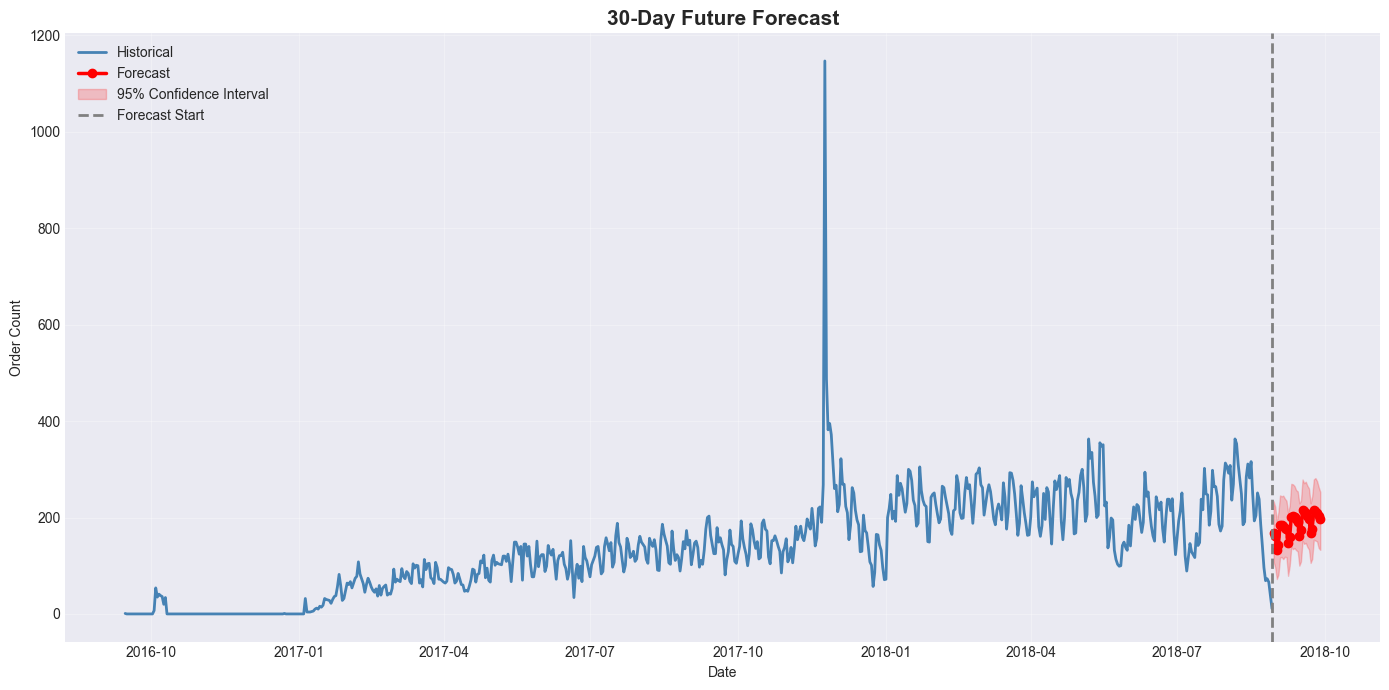

In [55]:
# Plot 30-day future forecast

fig, ax = plt.subplots(figsize=(14, 7))

# Historical series
ax.plot(
    ts_daily_complete.index,
    ts_daily_complete.values,
    label='Historical',
    color='steelblue',
    linewidth=2
)

# Forecast line
ax.plot(
    future_forecast['Date'],
    future_forecast['Forecast'],
    label='Forecast',
    color='red',
    linewidth=2.5,
    marker='o'
)

# Confidence interval
ax.fill_between(
    future_forecast['Date'],
    future_forecast['Lower Bound'],
    future_forecast['Upper Bound'],
    color='red',
    alpha=0.2,
    label='95% Confidence Interval'
)

# Forecast start line
ax.axvline(
    x=ts_daily_complete.index[-1],
    color='gray',
    linestyle='--',
    linewidth=2,
    label='Forecast Start'
)

ax.set_title('30-Day Future Forecast', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Order Count')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Forecast Visualisation Interpretation
The forecast visualisation shows that the future path remains broadly aligned with the **recent historical level** of the series, rather than projecting another extreme spike or structural shift. The predicted trajectory also preserves a visible **weekly rhythm**, which is consistent with the weekly effect identified earlier in the analysis. Importantly, the **confidence interval** around the forecast indicates that actual future demand may still vary noticeably around the central estimate. This means the forecast should be used as a **planning range** rather than as a single exact target, especially for decisions related to inventory and operational capacity.

## 8.3 Business Insights and Recommendations
Based on the descriptive analysis, decomposition results, anomaly detection, category comparison, and forecasting evaluation, several business implications can be drawn.

These recommendations focus on **marketing**, **inventory**, **operations**, and **category management**.

### Business Insights and Recommendations

#### Key Findings
1. The platform shows a clear **long-term growth trend** from late 2016 to mid-2018.
2. The series contains a strong **weekday effect**, with **Monday** showing the highest demand and **Saturday** the weakest.
3. A major **anomalous spike** appears around late 2017, suggesting the presence of event-driven demand surges.
4. The **top categories** share the overall growth pattern, but differ in their **volatility** and **weekly concentration**.
5. Among the tested forecasting models, **Exponential Smoothing** performs best on `MAE`, while **Prophet** performs best on `RMSE` and `MAPE`.
6. The **30-day forecast** suggests relatively stable short-term demand with meaningful uncertainty around the central estimate.

#### Recommendations
- **Marketing**: Schedule major campaigns around stronger **weekday demand**, especially at the beginning of the week.
- **Inventory**: Use the forecast interval rather than only the point forecast when preparing stock levels.
- **Operations**: Allocate more support and fulfilment capacity on **high-demand weekdays** and during active daytime hours.
- **Category Strategy**: Apply differentiated planning across major categories, since they do not follow identical **time dynamics**.
- **Risk Monitoring**: Investigate the causes of past anomalies and monitor similar periods closely in future business planning.

## 9. Save Results and Project Summary
The final step is to save the main analytical outputs and summarise the overall project findings.

This helps turn the notebook into a more complete **portfolio-ready** business analysis project.

## 9.1 Save Key Results
To make the outputs reusable, the main forecast, model comparison, anomaly results, and monthly statistics are saved as `.csv` files.

This improves the practical value of the project and supports later reporting or dashboard development.

In [56]:
# Create output folder
import os

output_dir = "output/05_time_series_analysis"
os.makedirs(output_dir, exist_ok=True)

print(f"Output folder created: {output_dir}")

Output folder created: output/05_time_series_analysis


In [57]:
# Save future forecast
future_forecast.to_csv(
    f"{output_dir}/future_30day_forecast.csv",
    index=False,
    encoding='utf-8-sig'
)

print("Saved: future_30day_forecast.csv")

Saved: future_30day_forecast.csv


In [58]:
# Save model comparison table
model_comparison.to_csv(
    f"{output_dir}/model_comparison.csv",
    index=False,
    encoding='utf-8-sig'
)

print("Saved: model_comparison.csv")

Saved: model_comparison.csv


In [59]:
# Save anomaly results
anomalies_df = pd.DataFrame({
    'date': anomalies.index,
    'residual': anomalies.values
})

anomalies_df.to_csv(
    f"{output_dir}/anomalies.csv",
    index=False,
    encoding='utf-8-sig'
)

print("Saved: anomalies.csv")

Saved: anomalies.csv


In [60]:
# Save monthly statistics
df_monthly.to_csv(
    f"{output_dir}/monthly_statistics.csv",
    index=False,
    encoding='utf-8-sig'
)

print("Saved: monthly_statistics.csv")

Saved: monthly_statistics.csv


In [61]:
# Final check
print("All files saved successfully.")
print(os.listdir(output_dir))

All files saved successfully.
['anomalies.csv', 'future_30day_forecast.csv', 'model_comparison.csv', 'monthly_statistics.csv']


### Result Saving Reflection
The main analytical outputs have been saved in structured `.csv` format, which makes the project easier to reuse in later reporting, dashboard building, or portfolio presentation.

This also strengthens the project as a more complete **business analytics workflow** rather than only a notebook-based exercise.

## 9.2 Project Summary
This project analysed the e-commerce business from a **time series** perspective, covering descriptive trend analysis, decomposition, anomaly detection, category comparison, and short-term forecasting.

The final summary should highlight both the **technical workflow** and the **business value** of the project.

# Project Summary

## Objectives Achieved
- Analysed business patterns at **daily**, **monthly**, **weekly**, and **hourly** levels
- Identified the series’ **trend**, **seasonal**, and **residual** structure
- Detected abnormal fluctuations through **anomaly detection**
- Compared temporal dynamics across major product categories
- Built and evaluated multiple forecasting models
- Generated a **30-day future forecast** with confidence intervals
- Derived practical business recommendations for planning and operations

## Key Findings
- The platform shows a clear **long-term upward trend**
- Demand is concentrated on **weekdays**, especially **Monday**
- The series contains a major **abnormal spike** around late 2017
- Major categories share the overall growth pattern but differ in volatility and weekly rhythm
- **Exponential Smoothing** performs best on `MAE`
- **Prophet** performs best on `RMSE` and `MAPE`
- The short-term forecast suggests a relatively **stable future demand level** with meaningful uncertainty

## Technical Highlights
- **Daily time series construction** from transactional data
- **Seasonal decomposition**
- **ADF stationarity test**
- **ACF / PACF** analysis
- **IQR-based anomaly detection**
- Forecasting models: **Naive**, **Moving Average**, **ARIMA**, **Exponential Smoothing**, **Prophet**
- Model evaluation using `MAE`, `RMSE`, and `MAPE`

## Business Value
- Supports **inventory preparation** through short-term demand forecasting
- Helps optimise **marketing timing** using weekday and hourly demand patterns
- Improves **operational planning** by identifying demand concentration and volatility
- Provides an analytical basis for monitoring **abnormal events**
- Enhances data-driven decision-making in e-commerce business management

### Final Reflection
This project shows that **time series analysis** is not only useful for forecasting, but also valuable for understanding how business performance evolves over time. A key insight is that strong business growth can coexist with substantial **short-term volatility**, which means that effective decision-making requires both structural trend analysis and uncertainty-aware forecasting.

From a methodological perspective, the project also highlights the importance of careful data treatment, including the distinction between **order-level** and **item-level** aggregation, the handling of incomplete time coverage, and the interpretation of abnormal points that do not follow regular seasonal behaviour. These considerations make the final analysis more robust and more meaningful from a real business perspective.